# Continuous Random Vector

Let $x_1, x_2, \ldots, x_d$ be $d$ continuous random variables.

**Continuous random vector** — a column vector of random variables:

$$\mathbf{x} = [x_1 \; x_2 \; \cdots \; x_d]^\top$$

**Mean vector** — expectation applied component-wise:

$$\boldsymbol{\mu} = E[\mathbf{x}] = \begin{bmatrix} E[x_1] \\ E[x_2] \\ \vdots \\ E[x_d] \end{bmatrix} \quad \text{where} \quad E[x_i] = \int x_i \, p(\mathbf{x}) \, d\mathbf{x}$$

**Variance vector** — per-component variance:

$$\boldsymbol{\sigma}^2 = \begin{bmatrix} E[(x_1 - \mu_1)^2] \\ E[(x_2 - \mu_2)^2] \\ \vdots \\ E[(x_d - \mu_d)^2] \end{bmatrix}$$

**Covariance matrix** — pairwise covariances between all components:

$$\Sigma = E[(\mathbf{x} - \boldsymbol{\mu})(\mathbf{x} - \boldsymbol{\mu})^\top] = \begin{bmatrix} \sigma_1^2 & \sigma_{12} & \cdots & \sigma_{1d} \\ \sigma_{21} & \sigma_2^2 & \cdots & \sigma_{2d} \\ \vdots & & \ddots & \vdots \\ \sigma_{d1} & \sigma_{d2} & \cdots & \sigma_d^2 \end{bmatrix}$$

where $\sigma_{ij} = E[(x_i - \mu_i)(x_j - \mu_j)]$ and $\Sigma$ is **symmetric** ($\sigma_{ij} = \sigma_{ji}$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from scipy.integrate import dblquad

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

## Example: 3-Dimensional Continuous Random Vector

Using a trivariate Normal distribution $\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \Sigma)$ with known parameters:

- $\boldsymbol{\mu} = [170, 65, 25]^\top$ (height cm, weight kg, BMI)
- $\Sigma$ encodes: height–weight positively correlated ($\sigma_{12}=40$), height–BMI weakly correlated ($\sigma_{13}=10$), weight–BMI positively correlated ($\sigma_{23}=20$)

We verify $\boldsymbol{\mu}$, $\boldsymbol{\sigma}^2$, and $\Sigma$ from samples and numerically.

In [2]:
# Analytic parameters
mu_true   = np.array([170.0, 65.0, 25.0])
Sigma_true = np.array([
    [100.0,  40.0,  10.0],
    [ 40.0,  64.0,  20.0],
    [ 10.0,  20.0,  16.0],
])

print("Analytic mean vector  μ:")
labels = ['x₁ (height)', 'x₂ (weight)', 'x₃ (BMI)']
for lbl, m in zip(labels, mu_true):
    print(f"  μ_{lbl[1]} = E[{lbl}] = {m:.1f}")

print()
print("Analytic variance vector  σ²  (diagonal of Σ):")
for i, (lbl, v) in enumerate(zip(labels, np.diag(Sigma_true))):
    print(f"  σ²_{i+1} = {v:.1f}  →  σ_{i+1} = {np.sqrt(v):.4f}")

print()
print("Analytic covariance matrix  Σ:")
col_header = "          " + "  ".join(f"{'x'+str(i+1):>8}" for i in range(3))
print(col_header)
for i, row in enumerate(Sigma_true):
    print(f"  x{i+1}  " + "  ".join(f"{v:8.1f}" for v in row))

print()
print(f"Symmetric (Σ = Σᵀ): {np.allclose(Sigma_true, Sigma_true.T)}")

Analytic mean vector  μ:
  μ_₁ = E[x₁ (height)] = 170.0
  μ_₂ = E[x₂ (weight)] = 65.0
  μ_₃ = E[x₃ (BMI)] = 25.0

Analytic variance vector  σ²  (diagonal of Σ):
  σ²_1 = 100.0  →  σ_1 = 10.0000
  σ²_2 = 64.0  →  σ_2 = 8.0000
  σ²_3 = 16.0  →  σ_3 = 4.0000

Analytic covariance matrix  Σ:
                x1        x2        x3
  x1     100.0      40.0      10.0
  x2      40.0      64.0      20.0
  x3      10.0      20.0      16.0

Symmetric (Σ = Σᵀ): True


## Estimating μ and Σ from Samples

Draw $N = 50{,}000$ samples from $\mathcal{N}(\boldsymbol{\mu}, \Sigma)$ and estimate $\hat{\boldsymbol{\mu}}$ and $\hat{\Sigma}$.

In [3]:
rng = np.random.default_rng(42)
N   = 50_000
dist = multivariate_normal(mean=mu_true, cov=Sigma_true)
samples = dist.rvs(size=N, random_state=rng)   # shape (N, 3)

mu_hat    = samples.mean(axis=0)
Sigma_hat = np.cov(samples.T)

print("Estimated vs analytic mean vector  μ:")
print(f"  {'Component':<14} {'μ analytic':>12} {'μ̂ estimated':>13} {'error':>10}")
print("  " + "─" * 52)
for i, (m_a, m_e) in enumerate(zip(mu_true, mu_hat)):
    print(f"  x{i+1}  {labels[i]:<12} {m_a:>12.4f} {m_e:>13.4f} {m_e-m_a:>10.4f}")

print()
print("Estimated vs analytic covariance matrix  Σ:")
print("  Analytic:")
for row in Sigma_true:
    print("   ", "  ".join(f"{v:8.2f}" for v in row))
print("  Estimated:")
for row in Sigma_hat:
    print("   ", "  ".join(f"{v:8.2f}" for v in row))
print()

# Verify outer-product formula: Σ = E[(x - μ)(x - μ)ᵀ]
x_c = samples - mu_hat
Sigma_outer = (x_c.T @ x_c) / (N - 1)
print(f"Outer-product formula matches np.cov: {np.allclose(Sigma_hat, Sigma_outer, atol=1e-8)}")
print(f"Symmetric: {np.allclose(Sigma_hat, Sigma_hat.T)}")

Estimated vs analytic mean vector  μ:
  Component        μ analytic  μ̂ estimated      error
  ────────────────────────────────────────────────────
  x1  x₁ (height)      170.0000      170.0592     0.0592
  x2  x₂ (weight)       65.0000       65.0432     0.0432
  x3  x₃ (BMI)          25.0000       25.0012     0.0012

Estimated vs analytic covariance matrix  Σ:
  Analytic:
      100.00     40.00     10.00
       40.00     64.00     20.00
       10.00     20.00     16.00
  Estimated:
      101.62     41.06     10.01
       41.06     64.75     20.16
       10.01     20.16     16.09

Outer-product formula matches np.cov: True
Symmetric: True


## Visualisation

Top row: marginal histograms for each component with mean marked.  
Bottom row: mean vector bar chart, variance vector bar chart, covariance matrix heatmap.

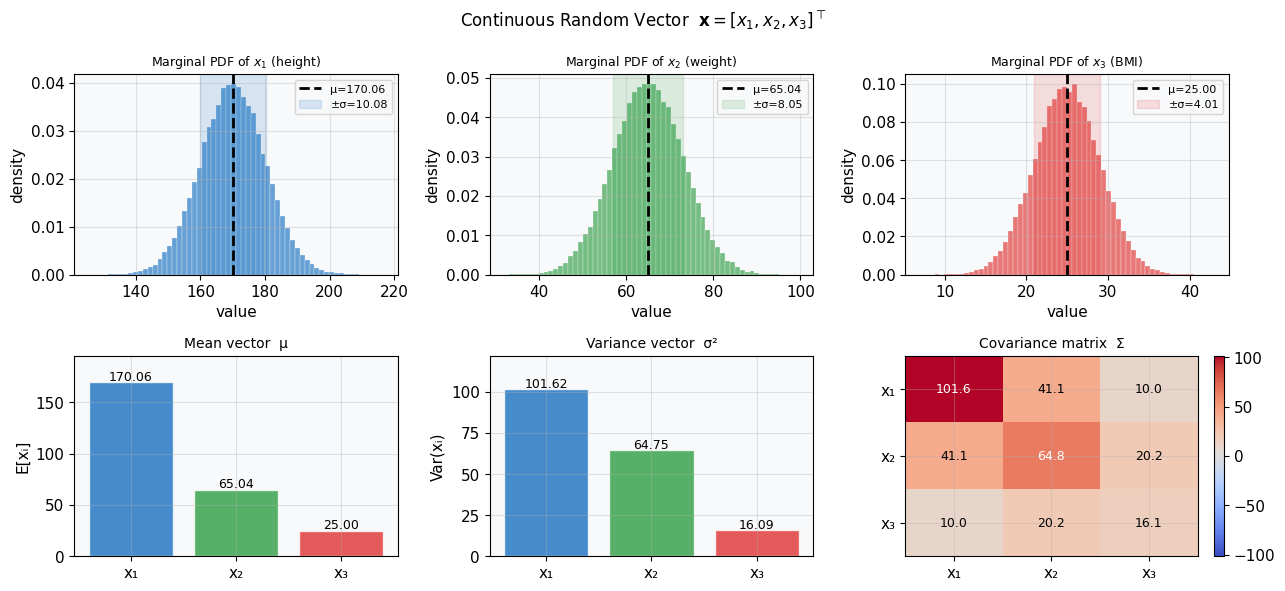

In [4]:
colors      = ['#1971c2', '#2f9e44', '#e03131']
comp_labels = ['$x_1$ (height)', '$x_2$ (weight)', '$x_3$ (BMI)']
short_lbls  = ['x₁', 'x₂', 'x₃']

fig, axes = plt.subplots(2, 3, figsize=(13, 6))

# Row 0: marginal histograms with mean and ±σ
for j in range(3):
    ax = axes[0, j]
    data = samples[:, j]
    ax.hist(data, bins=60, color=colors[j], alpha=0.65, density=True, edgecolor='white', lw=0.3)
    m, s = mu_hat[j], np.sqrt(Sigma_hat[j, j])
    ax.axvline(m, color='black', lw=2, ls='--', label=f'μ={m:.2f}')
    ax.axvspan(m - s, m + s, alpha=0.15, color=colors[j], label=f'±σ={s:.2f}')
    ax.set_title(f'Marginal PDF of {comp_labels[j]}', fontsize=9)
    ax.set_xlabel('value')
    ax.set_ylabel('density')
    ax.legend(fontsize=8)

# Row 1 left: mean vector bar chart
ax_mu = axes[1, 0]
bars = ax_mu.bar(short_lbls, mu_hat, color=colors, alpha=0.8, edgecolor='white')
for bar, v in zip(bars, mu_hat):
    ax_mu.text(bar.get_x() + bar.get_width()/2, v + max(mu_hat)*0.01,
               f'{v:.2f}', ha='center', fontsize=9)
ax_mu.set_title('Mean vector  μ', fontsize=10)
ax_mu.set_ylabel('E[xᵢ]')
ax_mu.set_ylim(0, max(mu_hat) * 1.15)

# Row 1 middle: variance vector bar chart
var_hat = np.diag(Sigma_hat)
ax_var = axes[1, 1]
bars2 = ax_var.bar(short_lbls, var_hat, color=colors, alpha=0.8, edgecolor='white')
for bar, v in zip(bars2, var_hat):
    ax_var.text(bar.get_x() + bar.get_width()/2, v + max(var_hat)*0.01,
                f'{v:.2f}', ha='center', fontsize=9)
ax_var.set_title('Variance vector  σ²', fontsize=10)
ax_var.set_ylabel('Var(xᵢ)')
ax_var.set_ylim(0, max(var_hat) * 1.2)

# Row 1 right: covariance matrix heatmap
ax_cov = axes[1, 2]
vmax = np.abs(Sigma_hat).max()
im = ax_cov.imshow(Sigma_hat, cmap='coolwarm', aspect='auto', vmin=-vmax, vmax=vmax)
ax_cov.set_xticks([0, 1, 2]); ax_cov.set_xticklabels(short_lbls)
ax_cov.set_yticks([0, 1, 2]); ax_cov.set_yticklabels(short_lbls)
ax_cov.set_title('Covariance matrix  Σ', fontsize=10)
for i in range(3):
    for j in range(3):
        txt_color = 'white' if abs(Sigma_hat[i, j]) > vmax * 0.55 else 'black'
        ax_cov.text(j, i, f'{Sigma_hat[i, j]:.1f}',
                    ha='center', va='center', fontsize=9, color=txt_color)
plt.colorbar(im, ax=ax_cov, fraction=0.046)

plt.suptitle(r'Continuous Random Vector  $\mathbf{x} = [x_1, x_2, x_3]^\top$', fontsize=12)
plt.tight_layout()
plt.show()

## Pairwise Scatter Plots

Scatter plots of each pair of components reveal the covariance structure visually.

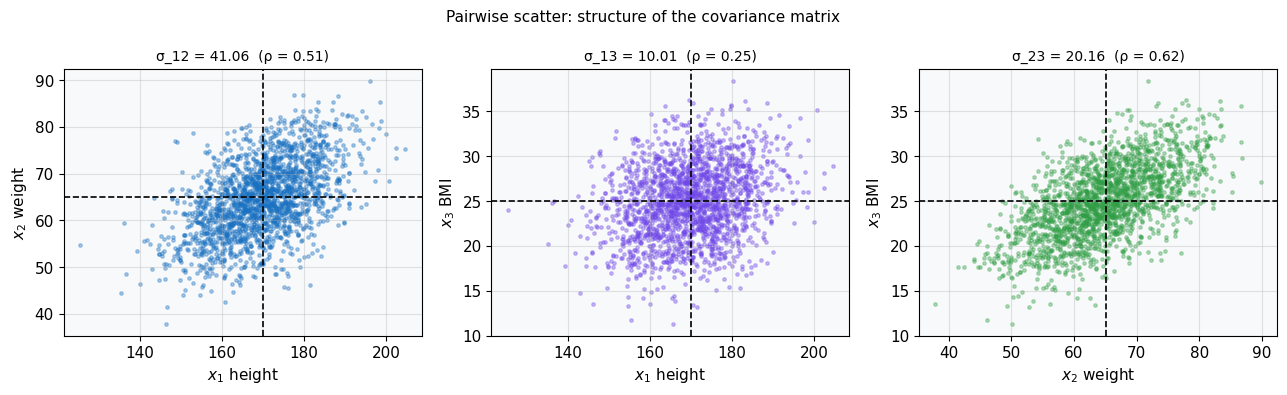

In [5]:
pairs = [(0, 1), (0, 2), (1, 2)]
pair_colors = ['#1971c2', '#7048e8', '#2f9e44']
pair_labels = [('$x_1$ height', '$x_2$ weight'),
               ('$x_1$ height', '$x_3$ BMI'),
               ('$x_2$ weight', '$x_3$ BMI')]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
# Sub-sample for plotting speed
idx = np.random.default_rng(0).choice(N, size=2000, replace=False)

for ax, (i, j), col, (xl, yl) in zip(axes, pairs, pair_colors, pair_labels):
    ax.scatter(samples[idx, i], samples[idx, j], s=6, alpha=0.35, color=col)
    ax.axvline(mu_hat[i], color='black', lw=1.2, ls='--')
    ax.axhline(mu_hat[j], color='black', lw=1.2, ls='--')
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    cov_ij = Sigma_hat[i, j]
    rho    = cov_ij / np.sqrt(Sigma_hat[i, i] * Sigma_hat[j, j])
    ax.set_title(f'σ_{i+1}{j+1} = {cov_ij:.2f}  (ρ = {rho:.2f})', fontsize=10)

plt.suptitle('Pairwise scatter: structure of the covariance matrix', fontsize=11)
plt.tight_layout()
plt.show()

## Summary

| Concept | Continuous RV | Discrete RV |
|---|---|---|
| **Random vector** | $\mathbf{x} = [x_1,\ldots,x_d]^\top$ | $\mathbf{X} = [X_1,\ldots,X_d]^\top$ |
| **Mean vector** | $\boldsymbol{\mu} = E[\mathbf{x}]$, $\mu_i = \int x_i\,p(\mathbf{x})\,d\mathbf{x}$ | $\mu_i = \sum x_i P(X_i=x_i)$ |
| **Variance vector** | $\sigma_i^2 = E[(x_i-\mu_i)^2]$ via integral | $\sigma_i^2 = E[(X_i-\mu_i)^2]$ via sum |
| **Covariance matrix** | $\Sigma = E[(\mathbf{x}-\boldsymbol{\mu})(\mathbf{x}-\boldsymbol{\mu})^\top]$ | same formula |
| **Diagonal of Σ** | Variances $\sigma_i^2$ | same |
| **Off-diagonal of Σ** | Covariances $\sigma_{ij}$ | same |
| **Symmetry** | $\sigma_{ij} = \sigma_{ji}$ | same |

The structure is identical — continuous uses integrals where discrete uses sums.